## *Project UAS Machine Learning Kel 13*

Judul: Prediksi Konsumsi Energi Bangunan Menggunakan Random Forest dan XGBoost untuk Mendukung Efisiensi Energi dalam Transisi Energi

Anggota: 

Rebriane Atitha Ginting (24031554039)

Nabilah Hilmi Rosanti (24031554053)

Kekila Akmal Nifcky (24031554144)

In [ ]:
# !pip install pandas
# !pip install matplotlib

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [10]:
DATA_DIR = Path("ashrae-energy-prediction")

In [11]:
print(DATA_DIR.exists())
print(list(DATA_DIR.iterdir()))

True
[PosixPath('ashrae-energy-prediction/weather_test.csv'), PosixPath('ashrae-energy-prediction/sample_submission.csv'), PosixPath('ashrae-energy-prediction/weather_train.csv'), PosixPath('ashrae-energy-prediction/test.csv'), PosixPath('ashrae-energy-prediction/train.csv'), PosixPath('ashrae-energy-prediction/building_metadata.csv')]


In [12]:
train = pd.read_csv(
    DATA_DIR / "train.csv",
    parse_dates=["timestamp"]
)

building = pd.read_csv(
    DATA_DIR / "building_metadata.csv"
)

weather = pd.read_csv(
    DATA_DIR / "weather_train.csv",
    parse_dates=["timestamp"]
)

print("Train shape:", train.shape)
print("Building shape:", building.shape)
print("Weather shape:", weather.shape)

Train shape: (15410470, 4)
Building shape: (1449, 6)
Weather shape: (139773, 9)


In [13]:
train.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0
3,3,0,2016-01-01,0.0
4,4,0,2016-01-01,0.0


In [14]:
building.head()

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [15]:
weather.head()

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


## DATA WRANGLING

In [16]:
train_electric = train[train["meter"] == 0].copy()

print("Jumlah data meter listrik:", train_electric.shape)

Jumlah data meter listrik: (9212251, 4)


In [17]:
train_sample = train_electric.sample(
    n=min(500_000, len(train_electric)),
    random_state=42
).copy()

print("Jumlah data sampel:", train_sample.shape)

Jumlah data sampel: (500000, 4)


In [18]:
df = train_sample.merge(
    building,
    on="building_id",
    how="left"
)

In [19]:
df = df.merge(
    weather,
    on=["site_id", "timestamp"],
    how="left"
)

print("Dataset gabungan:", df.shape)

Dataset gabungan: (500000, 16)


In [20]:
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,544,0,2016-01-26 04:00:00,93.7400,3,Public services,110800,1972.0,NaN,2.2,NaN,-3.9,0.0,1023.0,240.0,1.5
1,872,0,2016-02-22 21:00:00,5.2917,8,Public services,3627,NaN,1.0,26.1,NaN,12.2,0.0,1013.9,230.0,3.6
2,826,0,2016-05-30 08:00:00,62.2500,8,Public services,19446,NaN,1.0,21.7,4.0,20.6,0.0,1015.5,160.0,1.5
3,1255,0,2016-05-22 22:00:00,18.2771,14,Office,23702,NaN,NaN,17.8,NaN,9.4,0.0,1009.6,140.0,2.6
4,222,0,2016-01-29 20:00:00,17.5200,2,Entertainment/public assembly,11935,1939.0,NaN,18.3,NaN,-3.3,0.0,1016.3,0.0,0.0


## EDA

In [24]:
df.info()
df.shape
df.columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   building_id         500000 non-null  int64         
 1   meter               500000 non-null  int64         
 2   timestamp           500000 non-null  datetime64[us]
 3   meter_reading       500000 non-null  float64       
 4   site_id             500000 non-null  int64         
 5   primary_use         500000 non-null  str           
 6   square_feet         500000 non-null  int64         
 7   year_built          231356 non-null  float64       
 8   floor_count         123217 non-null  float64       
 9   air_temperature     497719 non-null  float64       
 10  cloud_coverage      280446 non-null  float64       
 11  dew_temperature     497641 non-null  float64       
 12  precip_depth_1_hr   395024 non-null  float64       
 13  sea_level_pressure  457305 non-null  flo

,building_id,meter,timestamp,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,500000.00000,500000.0,500000,500000.000000,500000.000000,500000.000000,231356.000000,123217.000000,497719.000000,280446.000000,497641.000000,395024.000000,457305.000000,470053.000000,496774.000000
mean,705.04912,0.0,2016-05-20 23:27:25.725600,168.194062,6.730126,92557.030180,1968.283213,3.807721,17.343162,2.340237,9.297212,0.863264,1015.640600,176.168079,3.591157
min,0.00000,0.0,2016-01-01 00:00:00,0.000000,0.000000,283.000000,1900.000000,1.000000,-28.800000,0.000000,-35.000000,-1.000000,968.200000,0.000000,0.000000
25%,343.00000,0.0,2016-03-12 06:00:00,18.960000,3.000000,23012.000000,1950.000000,1.000000,10.600000,0.000000,2.200000,0.000000,1011.600000,80.000000,2.100000
50%,696.00000,0.0,2016-05-21 15:00:00,61.750000,5.000000,57811.000000,1970.000000,3.000000,18.300000,2.000000,10.600000,0.000000,1015.800000,180.000000,3.100000
75%,1060.00000,0.0,2016-07-29 22:00:00,167.250000,12.000000,115788.000000,1996.000000,5.000000,25.000000,4.000000,17.200000,0.000000,1019.800000,270.000000,5.000000
max,1448.00000,0.0,2016-10-07 07:00:00,8130.500000,15.000000,875000.000000,2017.000000,26.000000,47.200000,9.000000,26.100000,343.000000,1042.200000,360.000000,19.000000
std,414.59911,0.0,NaN,367.410473,4.937260,111723.701042,31.022660,3.371785,10.428973,2.547728,9.975003,8.230959,6.671979,110.777143,2.296751


In [25]:
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
missing_percent

floor_count           75.3566
year_built            53.7288
cloud_coverage        43.9108
precip_depth_1_hr     20.9952
sea_level_pressure     8.5390
wind_direction         5.9894
wind_speed             0.6452
dew_temperature        0.4718
air_temperature        0.4562
square_feet            0.0000
site_id                0.0000
primary_use            0.0000
meter                  0.0000
timestamp              0.0000
building_id            0.0000
meter_reading          0.0000
dtype: float64

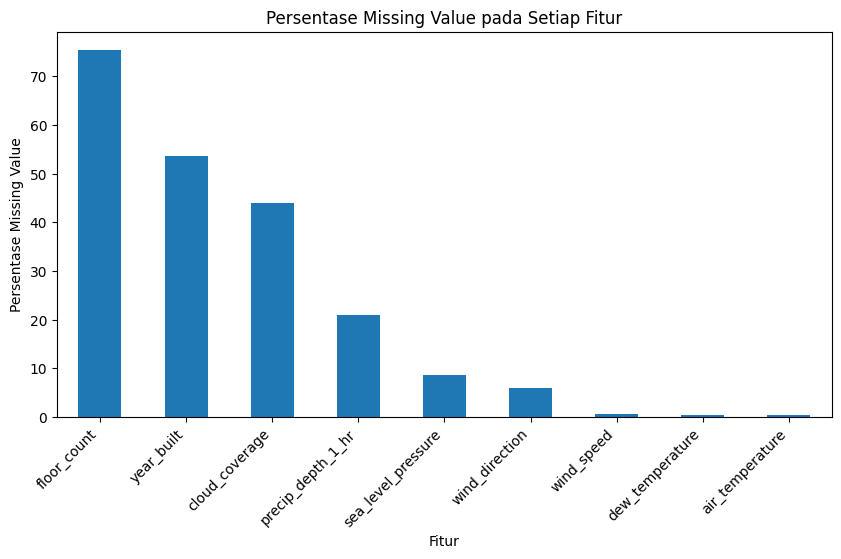

In [26]:
missing_plot = missing_percent[missing_percent > 0]

plt.figure(figsize=(10, 5))
missing_plot.plot(kind="bar")
plt.title("Persentase Missing Value pada Setiap Fitur")
plt.xlabel("Fitur")
plt.ylabel("Persentase Missing Value")
plt.xticks(rotation=45, ha="right")
plt.show()

### Cek Outlier Target

In [27]:
df["meter_reading"].describe()

count    500000.000000
mean        168.194062
std         367.410473
min           0.000000
25%          18.960000
50%          61.750000
75%         167.250000
max        8130.500000
Name: meter_reading, dtype: float64

In [28]:
df["meter_reading"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    1.00
])

0.500      61.75000
0.750     167.25000
0.900     413.36200
0.950     634.14985
0.990    1649.16250
0.995    2341.17140
1.000    8130.50000
Name: meter_reading, dtype: float64

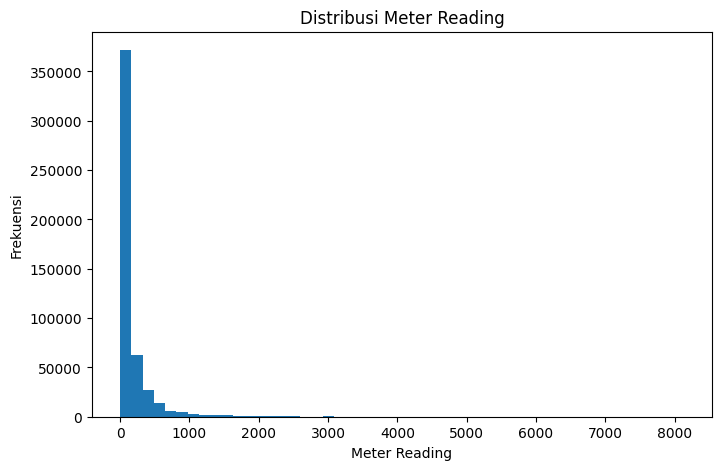

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df["meter_reading"], bins=50)
plt.title("Distribusi Meter Reading")
plt.xlabel("Meter Reading")
plt.ylabel("Frekuensi")
plt.show()

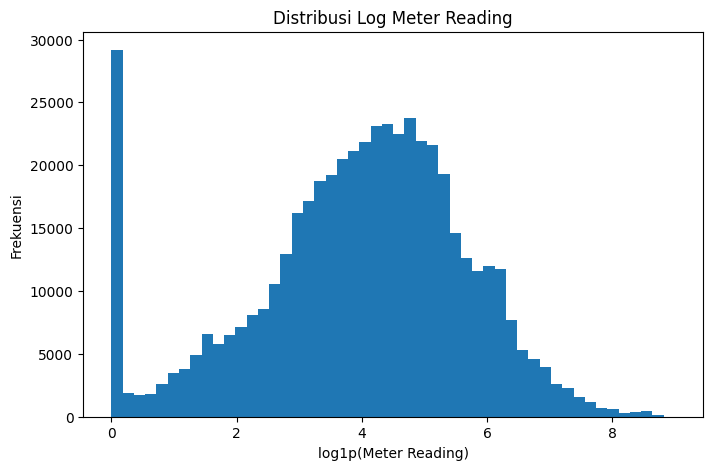

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["meter_reading"]), bins=50)
plt.title("Distribusi Log Meter Reading")
plt.xlabel("log1p(Meter Reading)")
plt.ylabel("Frekuensi")
plt.show()

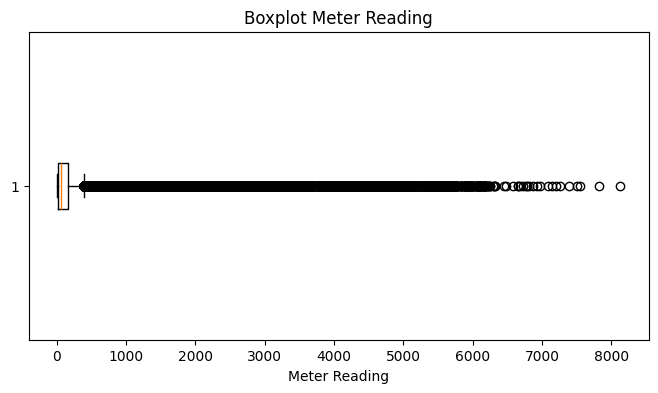

In [31]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["meter_reading"], vert=False)
plt.title("Boxplot Meter Reading")
plt.xlabel("Meter Reading")
plt.show()

### EDA Pola Waktu

In [32]:
df_eda = df.copy()

df_eda["hour"] = df_eda["timestamp"].dt.hour
df_eda["month"] = df_eda["timestamp"].dt.month
df_eda["weekday"] = df_eda["timestamp"].dt.weekday

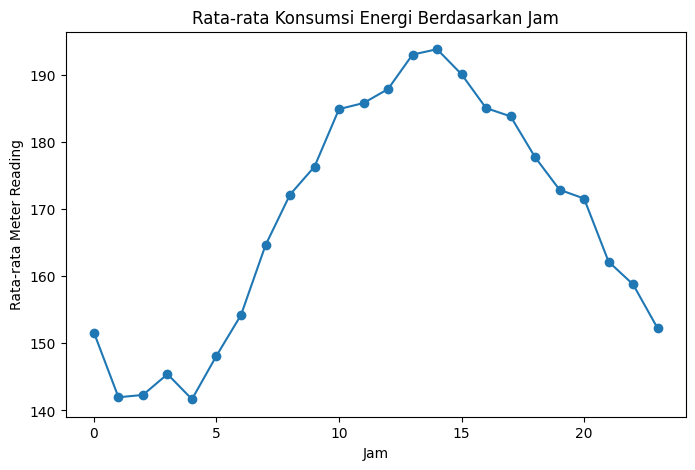

In [33]:
energy_by_hour = df_eda.groupby("hour")["meter_reading"].mean()

plt.figure(figsize=(8, 5))
plt.plot(energy_by_hour.index, energy_by_hour.values, marker="o")
plt.title("Rata-rata Konsumsi Energi Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Meter Reading")
plt.show()

### EDA Fungsi Bangunan

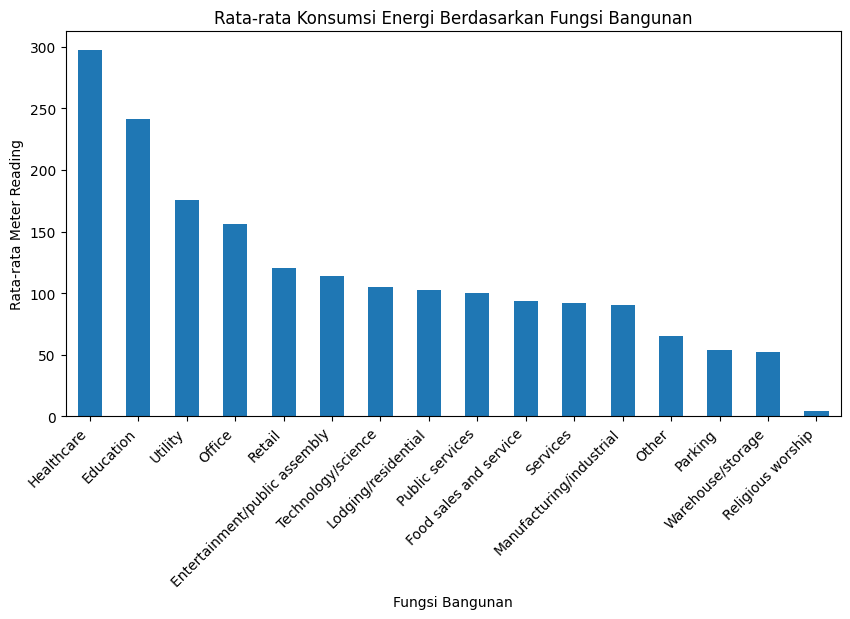

In [34]:
energy_by_use = (
    df_eda
    .groupby("primary_use")["meter_reading"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
energy_by_use.plot(kind="bar")
plt.title("Rata-rata Konsumsi Energi Berdasarkan Fungsi Bangunan")
plt.xlabel("Fungsi Bangunan")
plt.ylabel("Rata-rata Meter Reading")
plt.xticks(rotation=45, ha="right")
plt.show()

## PRE-PROCESSING

In [35]:
df = df[df["meter_reading"] >= 0].copy()

print("Dataset setelah filter target valid:", df.shape)

Dataset setelah filter target valid: (500000, 16)


### Feature Engineering

In [36]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

In [37]:
df["log_square_feet"] = np.log1p(df["square_feet"])

In [38]:
df["building_age"] = 2016 - df["year_built"]

In [39]:
target_col = "meter_reading"

feature_cols = [
    "building_id",
    "site_id",
    "meter",
    "primary_use",
    "square_feet",
    "log_square_feet",
    "year_built",
    "floor_count",
    "building_age",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend"
]

In [40]:
X = df[feature_cols].copy()

# Target ditransformasi log agar outlier tidak terlalu mendominasi model
y = np.log1p(df[target_col])

### Train-Test Split Berbasis Waktu

In [41]:
model_df = X.copy()
model_df["target_log"] = y
model_df["timestamp"] = df["timestamp"].values

model_df = model_df.sort_values("timestamp").reset_index(drop=True)

split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

In [42]:
X_train = train_df.drop(columns=["target_log", "timestamp"])
y_train = train_df["target_log"]

X_test = test_df.drop(columns=["target_log", "timestamp"])
y_test = test_df["target_log"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400000, 21)
X_test: (100000, 21)
y_train: (400000,)
y_test: (100000,)


### Missing Value Handling

In [43]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Kolom numerik:", list(num_cols))
print("Kolom kategorikal:", list(cat_cols))

Kolom numerik: ['building_id', 'site_id', 'meter', 'square_feet', 'log_square_feet', 'year_built', 'floor_count', 'building_age', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'is_weekend']
Kolom kategorikal: ['primary_use']


/tmp/ipykernel_2762/2869628809.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


In [44]:
numeric_medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(numeric_medians)
X_test[num_cols] = X_test[num_cols].fillna(numeric_medians)

In [45]:
X_train[cat_cols] = X_train[cat_cols].fillna("Unknown")
X_test[cat_cols] = X_test[cat_cols].fillna("Unknown")

In [46]:
print("Missing X_train:", X_train.isnull().sum().sum())
print("Missing X_test:", X_test.isnull().sum().sum())

Missing X_train: 0
Missing X_test: 0


In [47]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=list(cat_cols),
    drop_first=False,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=list(cat_cols),
    drop_first=False,
    dtype=int
)

In [48]:
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [49]:
print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)

X_train_encoded: (400000, 36)
X_test_encoded: (100000, 36)


In [50]:
X_train_encoded.head()

,building_id,site_id,meter,square_feet,log_square_feet,year_built,floor_count,building_age,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,day,month,weekday,is_weekend,primary_use_Education,primary_use_Entertainment/public assembly,primary_use_Food sales and service,primary_use_Healthcare,primary_use_Lodging/residential,primary_use_Manufacturing/industrial,primary_use_Office,primary_use_Other,primary_use_Parking,primary_use_Public services,primary_use_Religious worship,primary_use_Retail,primary_use_Services,primary_use_Technology/science,primary_use_Utility,primary_use_Warehouse/storage
0,714,5,0,8730,9.074635,1976.0,1.0,40.0,16.2,2.0,8.9,0.0,1015.7,190.0,3.1,0,1,1,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,417,3,0,69600,11.150534,1978.0,3.0,38.0,10.0,8.0,2.2,0.0,1021.1,350.0,4.1,0,1,1,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,674,5,0,149704,11.916422,1976.0,8.0,40.0,16.2,2.0,8.9,0.0,1015.7,190.0,3.1,0,1,1,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,481,3,0,104294,11.554979,1976.0,3.0,40.0,10.0,8.0,2.2,0.0,1021.1,350.0,4.1,0,1,1,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,44,0,0,283,5.648974,1985.0,3.0,31.0,25.0,6.0,20.0,0.0,1019.7,0.0,0.0,0,1,1,4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [51]:
X_train_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 36 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   building_id                                400000 non-null  int64  
 1   site_id                                    400000 non-null  int64  
 2   meter                                      400000 non-null  int64  
 3   square_feet                                400000 non-null  int64  
 4   log_square_feet                            400000 non-null  float64
 5   year_built                                 400000 non-null  float64
 6   floor_count                                400000 non-null  float64
 7   building_age                               400000 non-null  float64
 8   air_temperature                            400000 non-null  float64
 9   cloud_coverage                             400000 non-null  float64
 10  dew_temperature    

In [52]:
print("Jumlah missing X_train:", X_train_encoded.isnull().sum().sum())
print("Jumlah missing X_test:", X_test_encoded.isnull().sum().sum())

Jumlah missing X_train: 0
Jumlah missing X_test: 0


In [ ]:
# from pathlib import Path

# PROCESSED_DIR = Path("data_processed")
# PROCESSED_DIR.mkdir(exist_ok=True)

# X_train_encoded.to_csv(PROCESSED_DIR / "X_train_encoded.csv", index=False) #untuk modeling
# X_test_encoded.to_csv(PROCESSED_DIR / "X_test_encoded.csv", index=False) #untuk menguji dan mengevaluasi model

# y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False) #untuk modeling
# y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=False) #untuk menguji dan mengevaluasi model

## MODELING

In [1]:
!pip install scikit-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 41.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 41.0 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 33.3 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 31.0 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]u12]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score

# Jika xgboost belum terpasang, jalankan dulu:
# !pip install xgboost

from xgboost import XGBRegressor